# Fundamentos de Ciencia de Datos - FCEx - UNICEN

# Unidad 5: Tests paramétricos y no paramétricos

## Clase Práctica 6: Test de hipótesis

Este Colab corresponde a la sexta clase práctica del curso Fundamentos de Ciencia de Datos, que se dicta en el 4to año de la carrera de Ingeniería de Sistemas de la Facultad de Ciencias Exactas de la UNICEN.

La clase de hoy se enfoca en comparación de grupos mediante tests de hipótesis.


## 1 - Descargamos los datos

Vamos a trabajar con un conjunto de datos sobre expectativa de vida de la OMS, provenientes de este [sitio de Kaggle](https://www.kaggle.com/datasets/lashagoch/life-expectancy-who-updated?resource=download). Se trata del conjunto Life Expectancy (WHO) Fixed, que tiene registros con información asociada a la expectativa de vida en 179 países, con estadísticas entre 2000 y 2015. Para cada país y año incluye la esperanza de vida y variables de salud, vacunación, población y economía, lo que permite explorar diferencias entre países y posibles asociaciones con la esperanza de vida

Esta es una versión corregida de un conjunto de datos que vamos a usar en la práctica 8, pero que nos va a resultar práctica de trabajar porque no tiene valores faltantes, ruido, etc.

Vamos a descargarlo y analizarlo por arriba, primero:


In [ ]:
!pip install wget

import wget
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

from os import path

# inicializamos un diccionario donde guardaremos el dataset
dataset = dict()
dataset['url'] = 'https://ignaciorlando.github.io/datasets/data-science/Life-Expectancy-Data-Updated.csv'
dataset['extension'] = '.csv'
dataset['filename'] = 'life_expectancy' + dataset['extension']
!rm -rf {dataset['filename']}
wget.download(dataset['url'], dataset['filename'])

# accedemos a los datos usando Pandas
original_table = pd.read_table(dataset['filename'],sep=',')
original_table.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


Vamos a usar info() primero para ver la lista de variables:

In [ ]:
original_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   object 
 1   Region                       2864 non-null   object 
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita    

Vemos que el archivo tiene 21 columnas, en las que cada fila describe un país en un año determinado. Las variables que observamos son:

| Variable                      | Qué representa                                                                                                                                                                                                                                                                                        |
| ----------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `Country`                     | Nombre del país.                                                                                                                                                                                                                                                                                      |
| `Region`                      | Región geográfica a la que pertenece el país.                                                                                                                                                                                                                                                         |
| `Year`                        | Año al que corresponden los indicadores.                                                                                                                                                                                                                                                              |
| `Infant_deaths`               | Mortalidad de menores de un año, expresada por cada 1.000 según la descripción del conjunto.                                                                                                                                                                                                          |
| `Under_five_deaths`           | Mortalidad de menores de cinco años, expresada por cada 1.000 según la descripción del conjunto.                                                                                                                                                                                                      |
| `Adult_mortality`             | Probabilidad de morir entre los 15 y los 60 años, expresada por cada 1.000 personas que llegan a los 15 años. [Definición de la OMS](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/adult-mortality-rate-%28probability-of-dying-between-15-and-60-years-per-1000-population%29). |
| `Alcohol_consumption`         | Consumo de alcohol, medido en litros de alcohol puro por persona.                                                                                                                                                                                                                                     |
| `Hepatitis_B`                 | Cobertura de vacunación contra la hepatitis B, en porcentaje.                                                                                                                                                                                                                                         |
| `Measles`                     | Cobertura de vacunación contra el sarampión, en porcentaje. **No es el número de casos de sarampión.**                                                                                                                                                                                                |
| `BMI`                         | Índice de masa corporal promedio de la población adulta.                                                                                                                                                                                                                                              |
| `Polio`                       | Cobertura de vacunación contra la poliomielitis, en porcentaje.                                                                                                                                                                                                                                       |
| `Diphtheria`                  | Cobertura de vacunación contra difteria, tétanos y tos convulsa, en porcentaje.                                                                                                                                                                                                                       |
| `Incidents_HIV`               | Incidencia de VIH: nuevos casos registrados por cada 1.000 personas.                                                                                                                                                                                                                                  |
| `GDP_per_capita`              | Producto bruto interno por habitante, expresado en dólares estadounidenses.                                                                                                                                                                                                                           |
| `Population_mln`              | Población total del país, en millones de habitantes.                                                                                                                                                                                                                                                  |
| `Thinness_ten_nineteen_years` | Prevalencia de delgadez o bajo peso entre personas de 10 a 19 años, en porcentaje.                                                                                                                                                                                                                    |
| `Thinness_five_nine_years`    | Prevalencia de delgadez o bajo peso entre niños de 5 a 9 años, en porcentaje.                                                                                                                                                                                                                         |
| `Schooling`                   | Promedio de años de educación formal completados por la población de 25 años o más.                                                                                                                                                                                                                   |
| `Economy_status_Developed`    | Indicador binario: vale `1` si el país está clasificado como desarrollado y `0` en caso contrario.                                                                                                                                                                                                    |
| `Economy_status_Developing`   | Indicador binario: vale `1` si el país está clasificado como en desarrollo y `0` en caso contrario. Es complementario del indicador anterior.                                                                                                                                                         |
| `Life_expectancy`             | Esperanza de vida al nacer, expresada en años.                                                                                                                                                                                                                                                        |


Como dijimos antes, el conjunto tiene estadísticas de varios años, por lo que vamos a ver que hay filas que no son independientes entre sí (por ejemplo, datos de un mismo país pero de años distintos). Para poder trabajar con datos independientes, entonces, vamos a quedarnos solamente con los del 2015:

In [ ]:
# nos quedamos solamente con la data de 2015
data_2015 = original_table[original_table['Year'] == 2015]
data_2015.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
6,Russian Federation,Rest of Europe,2015,6.6,8.2,223.0000,8.06,97,97,26.2,...,97,0.08,9313,144.10,2.3,2.3,12.0,0,1,71.2
27,Cameroon,Africa,2015,57.0,88.0,340.1265,4.55,84,64,24.3,...,84,1.12,1383,23.30,5.6,5.5,6.1,0,1,57.6
43,"Gambia, The",Africa,2015,39.7,59.8,261.7065,2.69,97,64,23.9,...,97,0.96,661,2.09,7.3,7.2,3.4,0,1,60.9


Y ahora podemos volver a usar todas las herramientas de estadística descriptiva que en su momento habíamos utilizado en las unidades anteriores. Empecemos con un describe()

In [ ]:
# miremos primero las estadísticas globales del conjunto
data_2015.describe()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,179.0,179.000000,179.000000,179.00000,179.000000,179.000000,179.000000,179.000000,179.00000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000
mean,2015.0,23.558659,31.680447,163.66757,4.728994,87.100559,80.229050,25.596089,88.26257,87.916201,0.609777,12617.296089,40.087933,4.549721,4.593855,8.360894,0.206704,0.793296,71.463687
std,0.0,21.487508,32.217096,89.95447,3.743322,14.167575,16.185999,2.191669,13.02432,14.693831,1.621318,17719.612926,146.506422,4.115992,4.195546,3.146986,0.406077,0.406077,7.832270
min,2015.0,1.800000,2.300000,49.38400,0.000000,22.000000,21.000000,20.500000,37.00000,16.000000,0.010000,306.000000,0.090000,0.100000,0.100000,1.400000,0.000000,0.000000,50.900000
25%,2015.0,6.650000,7.850000,90.78575,1.360000,82.500000,64.000000,23.800000,85.00000,85.500000,0.080000,1690.000000,2.215000,1.500000,1.500000,5.950000,0.000000,1.000000,66.300000
50%,2015.0,15.200000,17.500000,146.51950,4.040000,92.000000,84.000000,26.200000,93.00000,93.000000,0.140000,5391.000000,9.110000,3.500000,3.400000,8.700000,0.000000,1.000000,73.000000
75%,2015.0,36.550000,49.950000,215.64925,7.760000,97.000000,94.000000,27.000000,97.00000,97.000000,0.370000,14274.500000,27.445000,6.500000,6.450000,11.050000,0.000000,1.000000,76.850000
max,2015.0,95.100000,140.200000,513.47550,16.720000,99.000000,99.000000,32.100000,99.00000,99.000000,14.300000,105462.000000,1379.860000,26.700000,27.300000,14.100000,1.000000,1.000000,83.800000


## 2 - ¿Cómo construimos una buena hipótesis?

Para construir una hipótesis, lo primero que necesitamos es algo de conocimiento del dominio. Por eso normalmente las hipótesis o bien llegan de los especialistas que nos proveen de los datos, o de los stakeholders interesados en que le encontremos respuestas a sus preguntas. En nuestro caso, estamos trabajando con conjuntos de datos a los que podemos aplicarles ciertas lógicas del sentido común, para poder construir algunas ideas.

1. ¿Los países en vías de desarrollo tienen un producto per cápita menor al de los países desarrollados?
2. ¿Los países en vías de desarrollo gastan un menor porcentaje de su producto bruto en salud que los países desarrollados?
3. ¿Los países en vías de desarrollo tienen una expectativa de vida menor a los desarrollados?
4. ¿Hay una relación, entonces, entre el producto per cápita y el porcentaje del producto per cápita invertido en salud y la expectativa de vida?

Nuestro conjunto de datos tiene países desarrollados y en vías de desarrollo. Sabemos a ciencia cierta (¿lo sabemos?) que los primeros se caracterizan por tener ingresos per cápita más altos, lo que garantiza un acceso a mejores servicios de salud, que tiene un correlato sobre la expectativa de vida de la población. Entonces podríamos determinar que nuestra hipótesis central es, por ejemplo, que los países desarrollados (```Status == 1```) seguramente tengan una expectativa de vida mayor a aquellos en vías de desarrollo (```Status == 0```).

Como ven, fuimos construyendo paulatinamente una hipótesis, encadenando diferentes lógicas que deberíamos ir validando antes de llegar a una última hipótesis. Eso es lo que esperamos que sean capaces de construir cuando salgan de esta materia: toda esa ruta de análisis, de principio a fin, hasta llegar a una hipótesis que enriquezca el conocimiento al que se puede llegar a partir de estos datos.

**La mala noticia: a esos tests los van a tener que hacer uds 😈**. En la versión original del conjunto con el que trabajábamos, tenemos todos los datos de gasto que precisamos para responder eso (aunque sucios!).

En este no, **así que vamos a trabajar solamente con dos hipótesis:**

1. **¿Los países en vías de desarrollo tienen un producto per cápita menor al de los países desarrollados?**
2. **¿Los países en vías de desarrollo tienen más habitantes que los países desarrollados?**



## 3 - Validando hipótesis

### 3.1. - ¿Los países en vías de desarrollo tienen un producto per cápita menor al de los países desarrollados?

Para empezar, revisemos qué columnas nos ofrece la tabla:

In [ ]:
data_2015.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179 entries, 0 to 2848
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      179 non-null    object 
 1   Region                       179 non-null    object 
 2   Year                         179 non-null    int64  
 3   Infant_deaths                179 non-null    float64
 4   Under_five_deaths            179 non-null    float64
 5   Adult_mortality              179 non-null    float64
 6   Alcohol_consumption          179 non-null    float64
 7   Hepatitis_B                  179 non-null    int64  
 8   Measles                      179 non-null    int64  
 9   BMI                          179 non-null    float64
 10  Polio                        179 non-null    int64  
 11  Diphtheria                   179 non-null    int64  
 12  Incidents_HIV                179 non-null    float64
 13  GDP_per_capita          

Observamos que tenemos una columna ```GDP_per_capita```, que equivale al PBI per cápita, y dos columnas de ```Economy_status```, que indican si el país es o no es desarrollado. Analicémoslas:

In [ ]:
data_2015[["Country", "Economy_status_Developed", "Economy_status_Developing"]]


,Country,Economy_status_Developed,Economy_status_Developing
0,Turkiye,0,1
1,Spain,1,0
6,Russian Federation,0,1
27,Cameroon,0,1
43,"Gambia, The",0,1
...,...,...,...
2753,Tunisia,0,1
2820,"Venezuela, RB",0,1
2840,Djibouti,0,1
2846,Nicaragua,0,1


Vemos que cuando una es 1, la otra es cero, con lo cual podríamos resumirla en una sola columna (estamos usando variables dummy de gusto en este caso). Eliminemos la columna ```Economy_status_Developing``` y cambiemos el nombre de ```Economy_status_Developed``` a una columna booleana:

In [ ]:
data_2015 = data_2015.drop('Economy_status_Developing', axis=1)
data_2015 = data_2015.rename(columns={'Economy_status_Developed': 'Developed'})
data_2015

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Developed,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,0,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,1,82.8
6,Russian Federation,Rest of Europe,2015,6.6,8.2,223.0000,8.06,97,97,26.2,97,97,0.08,9313,144.10,2.3,2.3,12.0,0,71.2
27,Cameroon,Africa,2015,57.0,88.0,340.1265,4.55,84,64,24.3,77,84,1.12,1383,23.30,5.6,5.5,6.1,0,57.6
43,"Gambia, The",Africa,2015,39.7,59.8,261.7065,2.69,97,64,23.9,96,97,0.96,661,2.09,7.3,7.2,3.4,0,60.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2753,Tunisia,Africa,2015,14.8,17.2,91.3430,1.50,98,98,26.3,98,98,0.04,4095,11.18,6.5,6.4,7.0,0,75.9
2820,"Venezuela, RB",South America,2015,16.4,19.1,141.5540,6.21,87,83,26.7,87,87,0.40,17318,30.08,1.6,1.5,10.1,0,72.6
2840,Djibouti,Africa,2015,54.6,65.8,251.7490,0.32,84,82,24.0,84,84,0.22,2653,0.91,5.6,5.4,4.1,0,64.1
2846,Nicaragua,Central America and Caribbean,2015,16.6,19.4,148.4805,3.72,98,83,27.2,99,98,0.11,2050,6.22,1.8,1.7,6.5,0,73.6


#### 3.1.1. Análisis gráfico de la hipótesis

Ahora sí, veamos primero gráficamente qué ocurre con el producto per cápita de los países desarrollados en relación a aquellos en vías de desarrollo:

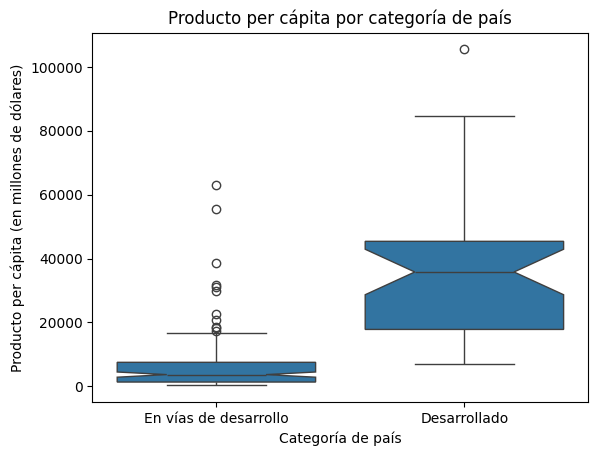

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Developed', y='GDP_per_capita', data=data_2015, notch=True)
plt.title("Producto per cápita por categoría de país")
plt.xlabel("Categoría de país")
plt.xticks(ticks=[0, 1], labels=["En vías de desarrollo", "Desarrollado"])
plt.ylabel("Producto per cápita (en millones de dólares)")
plt.show()


Vemos con claridad que efectivamente tenemos una diferencia pronunciada entre países desarrollados y en vías de desarrollo. Vemos además por los acogotamientos de ese boxplot que seguramente estas diferencias sean significativas estadísticamente. Ideal para hacer nuestro primer test de hipótesis.

En este caso, nos interesa validar la hipótesis de que los países desarrollados tienen un PBI per cápita mayor al de los países en vías de desarrollo. Como ambos grupos no están apareados, vamos a tener que recurrir a pruebas que comparan muestras desapareadas. Las opciones con las que contamos son **el test T para muestras independientes**, o el **test de Mann-Whitney U**. Pero, para poder avanzar, tenemos que primero validar los supuestos.

El test T es una prueba  paramétrica, por lo que primero debemos validar los supuestos de:

1. Normalidad de los datos: a través de un test de Shapiro-Wilk o de Kolmogorov-Smirnof
2. Homocedasticidad de varianzas: a través de un test de Levene o el de Bartlett.

El test de Mann-Whitney U requiere homocedasticidad de varianzas, solamente, porque compara medianas y no requiere que los datos se distribuyan normales.

A continuación vamos a validar esos supuestos y ver cuál de los tests es lícito hacer.

#### 3.1.2 - Validamos normalidad de los datos

Analicemos primero normalidad. Los dos tests para validar normalidad, Shapiro-Wilk y Kolmogorov-Smirnof, ya vienen implementados en Scipy, por lo que usaremos esas implementaciones.

Recordemos que en el test de Shapiro-Wilk, la hipótesis nula es la normalidad de los datos. En consecuencia, si el p-valor que obtenemos es menor a nuestro nivel de confianza $\alpha$ (normalmente $\alpha=0.05$), estamos entonces ante datos que no respetan una distribución normal:

In [ ]:
from scipy.stats import shapiro

# Separamos los datos en dos grupos, desarrollados y en vías de desarrollo
developed_countries = data_2015[data_2015['Developed'] == 1]['GDP_per_capita']
developing_countries = data_2015[data_2015['Developed'] == 0]['GDP_per_capita']

# Test de Shapiro-Wilk para países desarrollados
stat, p = shapiro(developed_countries)
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Test de Shapiro-Wilk para países en vías de desarrollo
stat, p = shapiro(developing_countries)
print(f"Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")


Test de Shapiro-Wilk para países desarrollados: Estadístico=0.917, p-valor=0.009
Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico=0.606, p-valor=0.000


Bueno, parece que los datos no son normales, según este test. Tiremos un test de Kolmogorov-Smirnov, ya que estamos, para que vean como se usa. Importante: a diferencia del Shapiro-Wilk, este test es más general y menos potente para detectar desviaciones sutiles de normalidad, pero puede aplicarse a muestras más grandes.

In [ ]:
from scipy.stats import kstest

# Test de Kolmogorov-Smirnov para países desarrollados
stat, p = kstest(developed_countries, 'norm')
print(f"Test de Kolmogorov-Smirnov para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Test de Kolmogorov-Smirnov para países en vías de desarrollo
stat, p = kstest(developing_countries, 'norm')
print(f"Test de Kolmogorov-Smirnov para países en vías de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")


Test de Kolmogorov-Smirnov para países desarrollados: Estadístico=1.000, p-valor=0.000
Test de Kolmogorov-Smirnov para países en vías de desarrollo: Estadístico=1.000, p-valor=0.000


Nuevamente vemos que se rechaza la hipótesis nula de normalidad, por lo que a las claras se trata de datos que no siguen una distribución normal.

¿Y qué nos dice, por ejemplo, un QQ plot, que es una herramienta también ampliamente difundida para estudiar normalidad? Recuerden que la interpretación se basa en qué tan cerca están los puntos de una línea recta: si están muy cerca, hay normalidad; si no, no la hay!

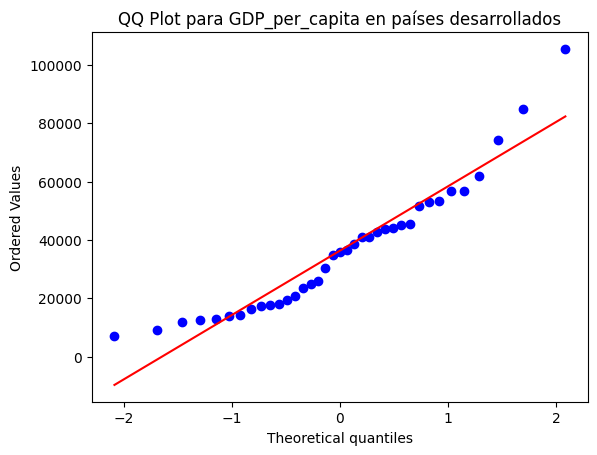

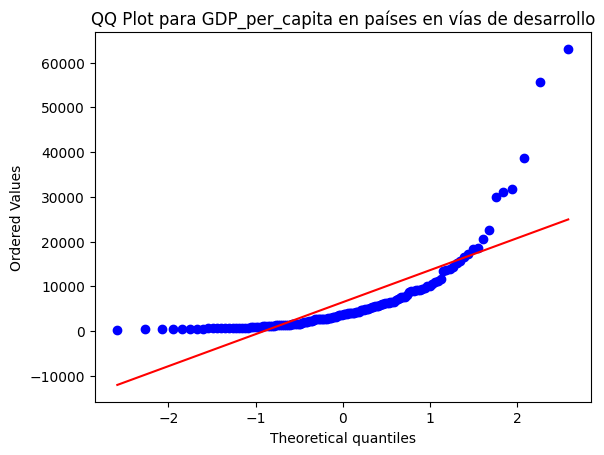

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# QQ plot para países desarrollados
stats.probplot(developed_countries, dist="norm", plot=plt)
plt.title("QQ Plot para GDP_per_capita en países desarrollados")
plt.show()

# QQ plot para países en vías de desarrollo
stats.probplot(developing_countries, dist="norm", plot=plt)
plt.title("QQ Plot para GDP_per_capita en países en vías de desarrollo")
plt.show()


Recuerden que el eje X representa los cuantiles de una distribución teórica (en este caso, una distribución normal), y el eje Y a los cuantiles de los datos observados. La línea diagonal representa la distribución teórica perfecta, y si los puntos siguen esta línea, los datos se ajustan bien a la distribución normal. En conclusión, **ni los dos tests ni el QQ-plot nos están mostrando normalidad en los datos, así que no podemos usar el test T**.



#### 3.1.3 - Validamos homocedasticidad

La homocedasticidad (o homogeneidad de varianzas) es un supuesto fundamental en varios tests. Se refiere a que las varianzas de los grupos que se están comparando deben ser aproximadamente iguales. En otras palabras, la dispersión o variabilidad de los datos dentro de cada grupo debe ser similar.

Los tests que tenemos disponibles son el de Levene (que es más robusto para distribuciones que no son normales) y el de Bartlett (que funciona en distribuciones normales). Como en este caso trabajamos con datos que no son normales, vamos a tirar un buen Levene a ver qué onda.

Ojo que en Levene la hipótesis nula es que las varianzas son significativamente diferentes entre sí (hay heterocedasticidad), por lo que pedimos que el test nos de un p-valor mayor a 0.05:

In [ ]:
stat, p = stats.levene(developed_countries, developing_countries)
print(f"Test de Levene para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")


Test de Levene para GDP_per_capita: Estadístico=50.924, p-valor=0.000


Bueno, obtuvimos un p-valor menor a 0.05, por ende tenemos datos que no son homocedasticos!

#### 3.1.4 - Validamos la hipótesis con Kruskal-Wallis

Dado que nuestro conjunto no cumple con ninguno de los supuestos que se necesitan para realizar la comparación de estos grupos, vamos a tener que recurrir al test de Kruskal-Wallis. La hipótesis nula del test es que no existen diferencias significativas entre los dos grupos provistos. Por consiguiente, si el p-valor del test nos da por debajo del umbral de significancia (acá abajo les puse una variable ```alpha``` en 0.05 para controlar eso), efectivamente hay una diferencia significativa entre ambos.

Hagamos el test usando también el paquete ```stats```:

In [ ]:
# Test de Kruskal-Wallis para comparar GDP_per_capita entre países desarrollados y en vías de desarrollo
stat, p = stats.kruskal(developed_countries, developing_countries)
print(f"Test de Kruskal-Wallis para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para GDP_per_capita: Estadístico=70.552, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.


Vemos que el p-valor que se obtuvo es muy pequeño (más pequeño que 0.001, por eso no lo vemos trabajando con 3 decimales), y que por ende **existen diferencias significativas en los valores de PBI per cápita de los países que estamos comparando**.

Ahora bien, esto no nos está diciendo quién es más grande que quien: solamente nos está indicando que hay diferencias en ambos grupos. Nosotros sabemos a priori que los países en vías de desarrollo efectivamente tienen un PBI menor porque lo vimos gráficamente, pero hay que tener mucho cuidado en el tipo de conclusión a la que sacamos... ¿porque eso no es lo que nos dijo el test!


### 3.2. ¿Los países en vías de desarrollo tienen más habitantes que los países desarrollados?

Si repasamos las columnas del archivo, vamos a ver que tenemos la columna ```Population_mln```, que indica la población de cada país en millones de habitantes. Podemos contrastar esta variable contra la variable de grupos con la que venimos trabajando, y a partir de ahí ir sacando nuestras conclusiones.

#### 3.2.1. Análisis gráfico de la hipótesis

Grafiquemos en un boxplot las diferencias poblacionales de ambos grupos de países:

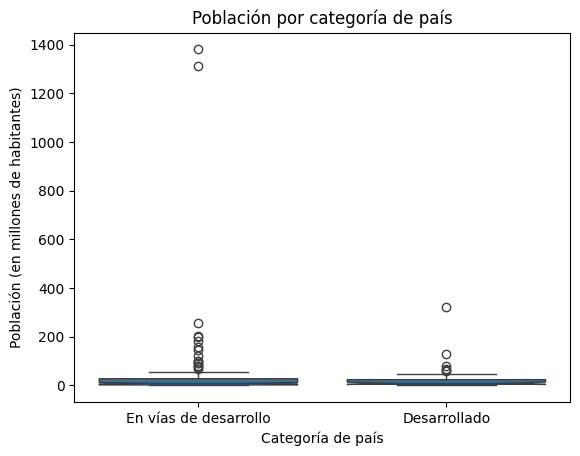

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Developed', y='Population_mln', data=data_2015, notch=True)
plt.title("Población por categoría de país")
plt.xlabel("Categoría de país")
plt.xticks(ticks=[0, 1], labels=["En vías de desarrollo", "Desarrollado"])
plt.ylabel("Población (en millones de habitantes)")
plt.show()

Vemos que la existencia de algunos outliers hace que no podamos analizar en buena medida el contenido del plot. Esto ocurre más a menudo de lo que pensamos, y dependiendo del objetivo del plot, podemos decidir si eliminar los outliers, o simplemente realizar un recorte en los ejes. Como acá estamos trabajando con un análisis exploratorio en torno a la hipótesis, no queremos perder esos outliers (¡vemos que hay muchos, además!), así que vamos a ir por la segunda opción.

Si observamos, la gran mayoría de los valores de población caen por debajo de más o menos los 100 millones de habitantes, así que recortemos el eje allí:

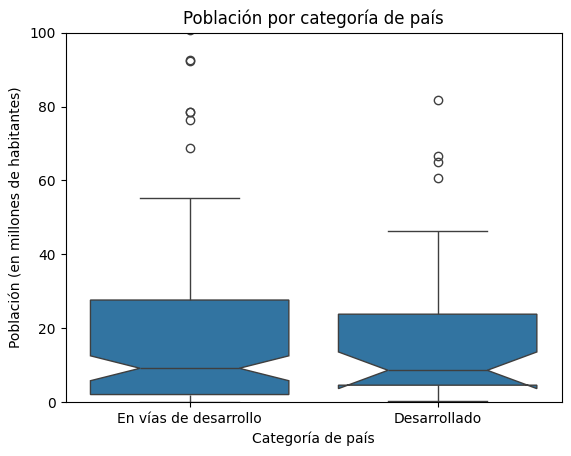

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Developed', y='Population_mln', data=data_2015, notch=True)
plt.title("Población por categoría de país")
plt.xlabel("Categoría de país")
plt.xticks(ticks=[0, 1], labels=["En vías de desarrollo", "Desarrollado"])
plt.ylim([0, 100])
plt.ylabel("Población (en millones de habitantes)")
plt.show()

Ahora vemos con un poco más de claridad que al menos las medianas se parecen bastante entre sí. Ahora bien, si miramos lo que ocurre con los países desarrollados, notaremos que el boxplot tiene un comportamiento algo extraño en su Q1: pareciera como si el Q1 "se metiera" dentro del notch. ¿Tendremos un bug? ¿Habremos hecho algo mal?

La respuesta es no. Y para entenderlo debemos recordar que los notches o acogotamientos del boxplot nos indican el intervalo de confianza del 95% en torno a la mediana. Esto lo que nos plantea es que el límite inferior del intervalo de confianza de la mediana es levemente superior al valor del Q1, y por eso lo vemos de esta forma.

¿Cuándo se dan estas situaciones? Bueno, hay varios factores que pueden influir:

- Puede que la muestra sea pequeña, y que la estimación del intervalo de confianza de la mediana no sea de fiar. En este caso no pareciera ser esa la causa.

- Puede que los datos tengan muchos outliers, lo que a priori no afecta el rango intercuartil (que es lo que representamos con el tamaño de la caja), pero sí puede afectar la estimación del intervalo de confianza de la mediana. Este sí pareciera ser el caso.

De cualquier forma, a priori nuestro test gráfico pareciera indicar que, a pesar de que hay muchos outliers del lado de los países en vías de desarrollo que están bastante por encima de los países desarrollados, las medianas son bastante similares entre sí.

¿Conclusión? Testeemos.

#### 3.2.2 - Validamos normalidad de los datos

Nuevamente validemos la normalidad de los datos, ahora usando Shapiro Wilk solamente:

In [ ]:
# Separamos los datos en dos grupos, desarrollados y en vías de desarrollo
developed_countries = data_2015[data_2015['Developed'] == 1]['Population_mln']
developing_countries = data_2015[data_2015['Developed'] == 0]['Population_mln']

# Test de Shapiro-Wilk para países desarrollados
stat, p = shapiro(developed_countries)
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Test de Shapiro-Wilk para países en vías de desarrollo
stat, p = shapiro(developing_countries)
print(f"Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países desarrollados: Estadístico=0.488, p-valor=0.000
Test de Shapiro-Wilk para países en vías de desarrollo: Estadístico=0.232, p-valor=0.000


Nuevamente parece que los datos no son normales, así que ya tenemos que descartar la posibilidad de usar un test paramétrico como el t para comparar ambos grupos.

#### 3.2.3 - Validamos homocedasticidad

Validemos ahora la homocedasticidad, para ver si tenemos que inclinarnos por un test de Kruskal Wallis, o ver si podemos usar un test Mann Whitney U:

In [ ]:
# Test de Levene para comparar Population_mln entre países desarrollados y en vías de desarrollo
stat, p = stats.levene(developed_countries, developing_countries)
print(f"Test de Levene para Population_mln: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para Population_mln: Estadístico=0.365, p-valor=0.547


Bueno, ahora sí estamos viendo un cambio respecto a lo que hicimos antes! Nuestro test indica que efectivamente nuestros datos son homocedasticos, con lo que podemos avanzar y usar un test que todavía no probamos... el de Mann Whitney!

#### 3.2.4 - Validamos la hipótesis con Mann Whitney U

Como nuestro conjunto ahora no cumple normalidad pero sí homocedasticidad, podemos recurrir al test de Mann Whitney U para evaluar la significancia estadística de las diferencias entre ambos grupos. Al igual que con el de Kruskal-Wallis, la hipótesis nula del test es que no existen diferencias significativas entre los dos grupos provistos. Por consiguiente, si el p-valor del test nos da por debajo del umbral de significancia, efectivamente hay una diferencia significativa entre ambos. Hagamos el test usando también el paquete ```stats```:

In [ ]:
# Test de Mann-Whitney U para comparar Population_mln entre países desarrollados y en vías de desarrollo
stat, p = stats.mannwhitneyu(developed_countries, developing_countries)
print(f"Test de Mann-Whitney U para Population_mln: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en la población entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en la población entre países desarrollados y en vías de desarrollo.")

Test de Mann-Whitney U para Population_mln: Estadístico=2763.000, p-valor=0.629
No hay suficiente evidencia para rechazar la hipótesis nula.
No hay una diferencia significativa en la población entre países desarrollados y en vías de desarrollo.


Bien! Nuestro test nos dio un p-valor bastante alto (0.629), lo que nos está indicando que efectivamente las diferencias no son significativas. Por consiguiente, **no podemos asegurar que las diferencias en las poblaciones entre los países desarrollados y en vías de desarrollo sean estadísticamente significativas**.

Si el test nos hubiera dado que efectivamente había diferencias, podríamos haber usado el test a una cola para poder validar si efectivamente ```Population_mln``` es menor en desarrollados que en los que están en vías de desarrollo. Pero no tiene sentido hacerlo en este caso porque ya sabemos que ambos grupos son estadísticamente similares. Si hubieran decidido hacerlo, tienen que pasarle al test la variable ```alternative=less``` (que indica que testean si el primer parámetro es estadísticamente inferior al segundo), o ```alternative=greater``` (si es al revés lo que quieren testear).


### 3.3. ¿Tenés algo personal contra el test t que no lo querés hacer?

![](https://i.imgflip.com/987yzm.jpg)

No, no tengo nada personal contra el test t. Al contrario, amaría que la vida fuera más simple y que pudiéramos disparar tests como trompada sin tener que chequear ningún supuesto. Peeeeero, los supuestos están para cumplirlos, y en este caso no tenemos ninguna variable que se distribuya normal en el conjunto (pueden testearlo uds mismos con un hermoso for como el que hice --y borré-- para armar la clase).

Pero quiero que hagan un test t, porque quiero que también vean cómo es que se corren.

Vamos a usar para eso uno de los conjuntos de ejemplos que usamos en la teoría: el [Iris Dataset](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html). Es un conjunto que se usa un montón en ciencia de datos para estudiar algunas cuestiones puntuales, y sí, es bastante aburrido también, no les va a permitir sacar ninguna conclusión divertida. Pero bueno, queremos hacer un test t así no se muere Laport, así que arranquemos con este!


#### 3.3.1. Planteemos una hipótesis en Iris

El Iris Dataset consiste en una serie de mediciones de longitud y ancho del pétalo y el sépalo de 3 tipos diferentes de una flor, [la Iris](https://es.wikipedia.org/wiki/Iris_(planta)), hecha obviamente para muchas flores distintas, pero de estas 3 variedades. Los tipos se llaman Setosa, Versicolor, y Virginica, y se ven así:

![](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png)

El dataset está disponible en Scikit Learn, así que es muy cómodo trabajar con él. Podemos usar para eso la función ```load_iris``` del paquete ```sklearn```, y traernos el conjunto completo.

Al cargarlo, van a notar que no está la variable ```tipo``` que indica exactamente el tipo de variante de planta. Esto es porque está planteada para resolver problemas de clasificación en machine learning, y en ese caso se separa siempre aparte, como variable objetivo. En este caso vamos a usar ese dato como variable para comparación de grupos, así que la vamos a incorporar en el conjunto:

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Cargar el conjunto de datos Iris
iris = load_iris()
data = iris.data
target = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Crear un DataFrame de pandas para facilitar el análisis
df = pd.DataFrame(data, columns=feature_names)

# Agregar la columna de las clases al DataFrame, reemplazando el valor numérico por el nombre de la clase
df["tipo"] = [target_names[i] for i in target]
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),tipo
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Vamos a plantear una hipótesis en función de las fotos que vimos de ejemplo: se ve claramente (al menos justo en esos casos) que la flor de la variante Setosa tiene un sépalo un toque más largo que la de la variante Virginica. Nuestra hipótesis, entonces, puede ser esa: **que las flores de la variante Setosa tienen un sépalo más largo de las Virginica**.

#### 3.3.2. Análisis gráfico de la hipótesis

Grafiquemos en un boxplot las diferencias entre los dos grupos:

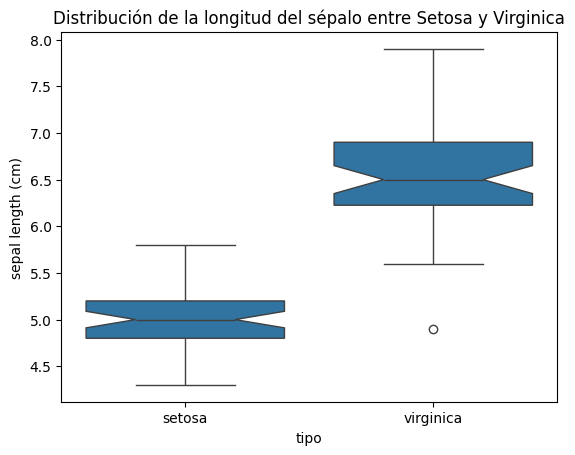

In [ ]:
# Crear un boxplot para comparar la longitud del sépalo entre Setosa y Virginica
sns.boxplot(x='tipo', y='sepal length (cm)', data=df[df['tipo'].isin(['setosa', 'virginica'])], notch=True)
plt.title('Distribución de la longitud del sépalo entre Setosa y Virginica')
plt.show()

Vemos con claridad que hay una diferencia bastante notoria entre ambos grupos, así que vamos en buen camino para poder correr de una vez por todas un buen test t.

#### 3.3.3 - Validamos normalidad de los datos

Usemos Shapiro Wilk para chequear normalidad:

In [ ]:
# Separamos el DataFrame en dos conjuntos
df_tipo_0 = df[df['tipo'] == "setosa"]
df_tipo_2 = df[df['tipo'] == "virginica"]

# Evaluamos normalidad de la variable sepal_length para setosa
stat, p = shapiro(df_tipo_0['sepal length (cm)'])
print(f"Test de Shapiro-Wilk para sepal_length (tipo=0): Estadístico={stat:.3f}, p-valor={p:.3f}")

# Evaluamos normalidad de la variable sepal_length para virginica
stat, p = shapiro(df_tipo_2['sepal length (cm)'])
print(f"Test de Shapiro-Wilk para sepal_length (tipo=1): Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para sepal_length (tipo=0): Estadístico=0.978, p-valor=0.460
Test de Shapiro-Wilk para sepal_length (tipo=1): Estadístico=0.971, p-valor=0.258


Vemos que efectivamente los datos presentan una distribución normal. Esto tiene bastante sentido si miramos el boxplot, donde vemos que los cuartiles Q1 y Q3 en ambos casos están bastante equidistantes en relación al rango de los datos y la mediana, ¿no?

#### 3.3.4 - Validamos homocedasticidad

Usamos un test de Levene ahora para chequear homocedasticidad:

In [ ]:
# Evaluamos homocedasticidad de la variable sepal_length
stat, p = stats.levene(df_tipo_0['sepal length (cm)'], df_tipo_2['sepal length (cm)'])
print(f"Test de Levene para sepal_length: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("Las varianzas de sepal_length son iguales entre setosa y virginica.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Las varianzas de sepal_length son diferentes entre setosa y virginica.")

Test de Levene para sepal_length: Estadístico=11.454, p-valor=0.001
Se rechaza la hipótesis nula.
Las varianzas de sepal_length son diferentes entre setosa y virginica.


MALDITA SEA! NO HAY HOMOSCEDASTICIDAD. Esto significa que no podemos correr un test t para comprobar si hay o no diferencias significativas.

#### 3.2.5 - Corramos al menos un test t para ver cómo se hace

Ya sabemos que no cumplimos con el supuesto de homoscedasticidad, por lo que tendríamos que validar con Mann-Whitney. Pero como queremos aprender a usar test t, hagamos ese test (aunque haciendo la salvedad de que es incorrecto). Vamos a usar la implementación del paquete ```stats``` de Scipy como hasta ahora:

In [ ]:
# Test t para comparar la longitud del sépalo entre Setosa y Virginica
t_statistic, p_value = stats.ttest_ind(df_tipo_0['sepal length (cm)'], df_tipo_2['sepal length (cm)'])
print(f"Test t para sepal length (cm): Estadístico={t_statistic:.3f}, p-valor={p_value:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p_value > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en la longitud del sépalo entre Setosa y Virginica.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en la longitud del sépalo entre Setosa y Virginica.")

Test t para sepal length (cm): Estadístico=-15.386, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en la longitud del sépalo entre Setosa y Virginica.


Vemos que si se cumplieran ambos supuestos, se confirmaría nuestra observación de que existen diferencias significativas en la distribución de esta variable. Pero bueno, no se cumplieron, así que ese análisis no es válido.

Ahora, imaginemos que fuera válido. Si fuera así, todavía no habríamos comprobado quién es mayor que quién (aunque tenemos muchísima evidencia a nuestro favor gracias al análisis gráfico que hicimos en la sección 3.3.1).

El test t también permite hacer comprobaciones a una cola, como las que planteamos posibles para el test de Mann Whitney U. En este caso, como vimos que las diferencias son significativas, hace sentido que demos ese paso extra y lo chequeemos:

In [ ]:
import scipy.stats as stats

# Test t a una cola para comparar la longitud del sépalo entre Setosa y Virginica
t_statistic, p_value = stats.ttest_ind(df_tipo_0['sepal length (cm)'], df_tipo_2['sepal length (cm)'], alternative='less')
print(f"Test t a una cola para sepal length (cm): Estadístico={t_statistic:.3f}, p-valor={p_value:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p_value > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en la longitud del sépalo entre Setosa y Virginica.")
else:
    print("Se rechaza la hipótesis nula.")
    print("La longitud del sépalo de Setosa es significativamente menor que la de Virginica.")

p_value

Test t a una cola para sepal length (cm): Estadístico=-15.386, p-valor=0.000
Se rechaza la hipótesis nula.
La longitud del sépalo de Setosa es significativamente menor que la de Virginica.


np.float64(3.4462730303370294e-28)

Y así lograríamos un p-valor que da sustento a nuestra hipótesis sobre la longitud del sépalo en estas variantes de Iris.

Bueno, ya queda poco, muchachxs, se va terminando el cuatrimestre. Así que alegría y coraje, que lo mejor está por venir! Y viva la universidad pública, ya que estamos!